In [1]:
import os
import numpy as np
import torch
from scipy.signal import resample_poly
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #Remember to install the GPU version of Pytorch!!!!!!
print(f"Using device: {device}")

Using device: cuda


In [3]:
class FRBnet(nn.Module):
    def __init__(self):
        super(FRBnet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1);    self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1);   self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, 1, 1);  self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, 1, 1); self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256, 512, 3, 1, 1); self.bn5 = nn.BatchNorm2d(512)
        self.conv6 = nn.Conv2d(512, 1024, 3, 1, 1);self.bn6 = nn.BatchNorm2d(1024)
        self.conv7 = nn.Conv2d(1024, 2048, 3, 1, 1);self.bn7 = nn.BatchNorm2d(2048)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(7 * 7 * 2048, 16384)
        self.fc2   = nn.Linear(16384, 8192)
        self.fc3   = nn.Linear(8192, 4096)
        self.fc4   = nn.Linear(4096, 2048)
        self.fc5   = nn.Linear(2048, 1)
        self.dropout = nn.Dropout(p=0)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.pool(F.relu(self.bn5(self.conv5(x))))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool(F.relu(self.bn7(self.conv7(x))))
        x = x.view(-1, self.num_flat_features(x))
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))
        x = self.dropout(F.relu(self.fc4(x)))
        return self.fc5(x)

    def num_flat_features(self, x):
        return np.prod(x.size()[1:])

In [ ]:
model = FRBnet()
checkpoint = torch.load('checkpoint_path\\weights_file.pth', map_location=device)
if any(k.startswith('module.') for k in checkpoint['state_dict'].keys()):
        model = nn.DataParallel(model)
model.load_state_dict(checkpoint['state_dict'])
model.to(device)
model.eval()

FRBnet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn6): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_runn

In [5]:
transform  = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((224, 224)),
        ])

['wfall', 'params']
torch.Size([1, 1, 224, 224])


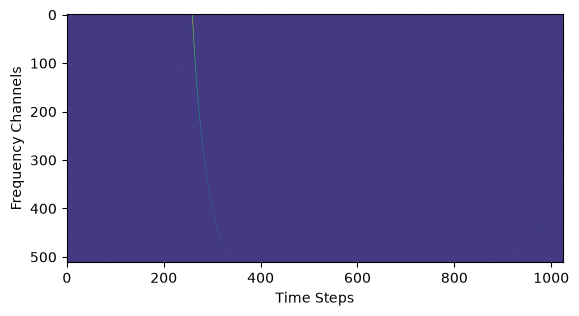

In [6]:
raw_data = np.load("data_path\\waterfall_data.npz", allow_pickle=True)
print(raw_data.files)
frbs = raw_data['wfall']
tensor_frbs = transform(frbs).unsqueeze(0).to(device)
print(tensor_frbs.shape)

plt.imshow(frbs)
plt.xlabel("Time Steps")
plt.ylabel("Frequency Channels")
plt.show()

In [7]:
with torch.no_grad():
    predicted_dm = model(tensor_frbs).item()
ground_truth_dm = raw_data['params'][0]

print(f'prediction: {predicted_dm}')
print(f'ground truth: {ground_truth_dm}')

prediction: 43.531883239746094
ground truth: 44.032238640718816
